In [1]:
import cv2

In [7]:
image = cv2.imread("test.jpeg")

In [3]:
print("Shape: ", image.shape)
print("Data Type: ", image.dtype)

Shape:  (527, 625, 3)
Data Type:  uint8


In [4]:
cv2.imshow("Original Image", image)
cv2.waitKey(0)
cv2.destroyAllWindows() 

In [9]:
cv2.imwrite("saved_image.jpeg", image)

True

In [10]:
image1 = cv2.imread("bloodcells.jpeg")
image2 = cv2.imread("Human_Blood_Smear.png")
image3 = cv2.imread("luffy.jpg")

print("Shape of image1: ", image1.shape)
print("Data type of image1: ", image1.dtype)
print("Shape of image2: ", image2.shape)
print("Data type of image2: ", image2.dtype)
print("Shape of image3: ", image3.shape)
print("Data type of image3: ", image3.dtype)



Shape of image1:  (860, 1290, 3)
Data type of image1:  uint8
Shape of image2:  (119, 120, 3)
Data type of image2:  uint8
Shape of image3:  (737, 415, 3)
Data type of image3:  uint8


In [11]:
cv2.imshow("Image 1", image1)
cv2.imshow("Image 2", image2)
cv2.imshow("Image 3", image3)

cv2.waitKey(0)
cv2.destroyAllWindows() 

In [13]:
cv2.imwrite("output/saved_image1.jpeg", image1)
cv2.imwrite("output/saved_image2.jpeg", image2)
cv2.imwrite("output/saved_image3.jpeg", image3)

True

In [14]:
import matplotlib.pyplot as plt

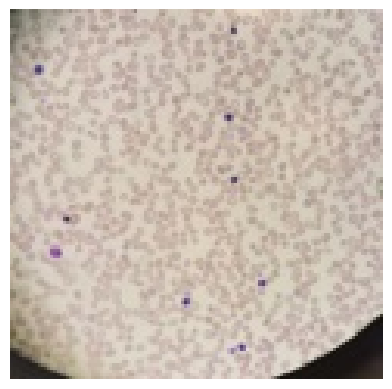

In [15]:
image = cv2.imread("output/saved_image2.jpeg")
rgp = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

plt.imshow(rgp)
plt.axis("off")
plt.show()

In [16]:
image = cv2.imread("output/saved_image3.jpeg")
#Resize 
small = cv2.resize(image, (200, 200))

#Crop
crop = image[200:400, 200:400]

#Flip
horizontal = cv2.flip(image, 1)
vertical = cv2.flip(image, 0)

cv2.imwrite("output/small_image.jpeg", small)
cv2.imwrite("output/cropped_image.jpeg", crop)
cv2.imwrite("output/horizontal_flip.jpeg", horizontal)
cv2.imwrite("output/vertical_flip.jpeg", vertical)

True

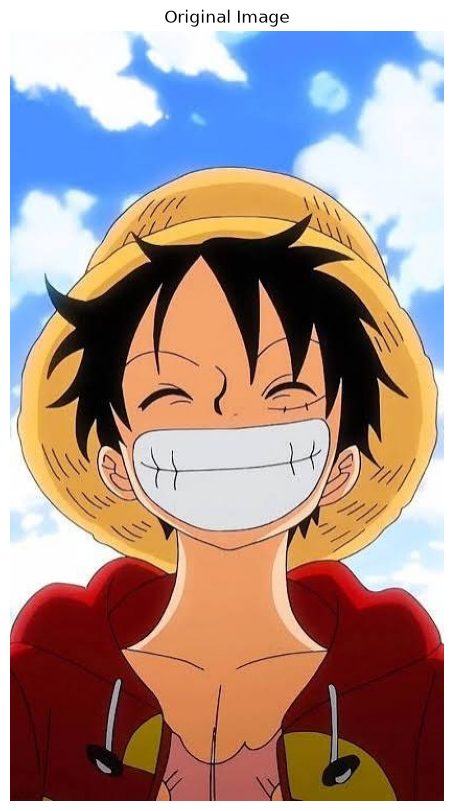

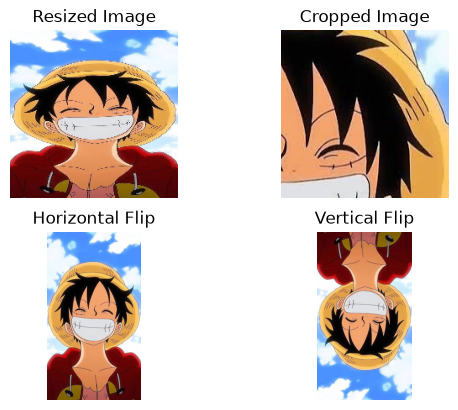

In [20]:
plt.figure(figsize=(10, 10))
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
plt.title("Original Image")
plt.axis("off")
plt.show()
plt.subplot(2, 2, 1)
plt.imshow(cv2.cvtColor(small, cv2.COLOR_BGR2RGB))
plt.title("Resized Image")
plt.axis("off")

plt.subplot(2, 2, 2)
plt.imshow(cv2.cvtColor(crop, cv2.COLOR_BGR2RGB))
plt.title("Cropped Image")
plt.axis("off")

plt.subplot(2, 2, 3)
plt.imshow(cv2.cvtColor(horizontal, cv2.COLOR_BGR2RGB))
plt.title("Horizontal Flip")
plt.axis("off")

plt.subplot(2, 2, 4)
plt.imshow(cv2.cvtColor(vertical, cv2.COLOR_BGR2RGB))
plt.title("Vertical Flip")
plt.axis("off")
plt.axis("off")
plt.show()

In [23]:
# Lab3 Rotation

height, width = image.shape[:2]
center = (width // 2, height // 2)

matrix = cv2.getRotationMatrix2D(center, -90, 1)

rotated = cv2.warpAffine(image, matrix, (width, height))

cv2.imwrite("output/rotated.jpg", rotated)

True

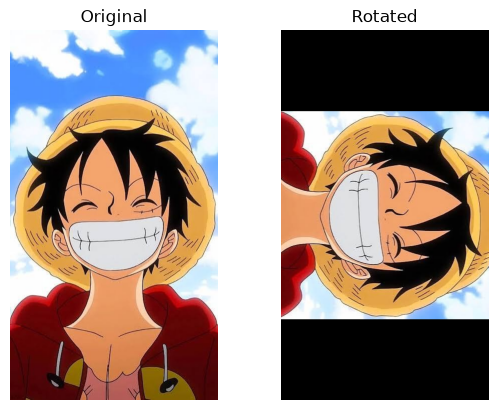

In [24]:
plt.subplot(1, 2, 1)
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
plt.title("Original")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(cv2.cvtColor(rotated, cv2.COLOR_BGR2RGB))
plt.title("Rotated")
plt.axis("off")

plt.show()

In [32]:
# Lab 4 Gray Scale
image = cv2.imread("test.jpeg", cv2.COLOR_BGR2RGB)
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
hsv = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)

print("Color: ", image.shape)
print("Shape of gray image: ", gray.shape)
print("Shape of HSV image: ", hsv.shape)

Color:  (527, 625, 3)
Shape of gray image:  (527, 625)
Shape of HSV image:  (527, 625, 3)


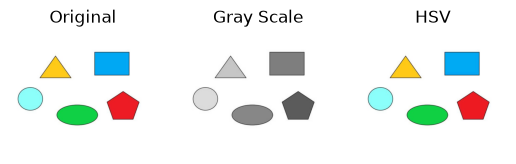

In [33]:
plt.subplot(1, 3, 1)
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
plt.title("Original")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(cv2.cvtColor(gray, cv2.COLOR_GRAY2RGB))
plt.title("Gray Scale")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(cv2.cvtColor(hsv, cv2.COLOR_HSV2RGB))
plt.title("HSV")
plt.axis("off")

plt.show()

In [34]:
# Lab 5
blur = cv2.blur(image, (5,5))
gaussian = cv2.GaussianBlur(image, (5,5), 0)
median = cv2.medianBlur(image, 5)

cv2.imwrite("blur/blur.jpeg", blur)
cv2.imwrite("blur/gaussian.jpeg", gaussian)
cv2.imwrite("blur/median.jpeg", median)

True

In [44]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

In [45]:
# Median Filter

image = cv2.imread("noisy_camera_man.webp", cv2.COLOR_BGR2RGB)

def median_filter(image, kernal_size=3):
    height, width = image.shape[:2]

    output = np.zeros_like(image)

    padding = kernal_size // 2

    for i in range(padding, height - padding):
        for j in range(padding, width - padding):
            window = image[i-padding:i+padding+1, j-padding:j+padding+1]
            output[i, j] = np.median(window)
    return output

In [49]:
filtered_image = median_filter(image, 5)

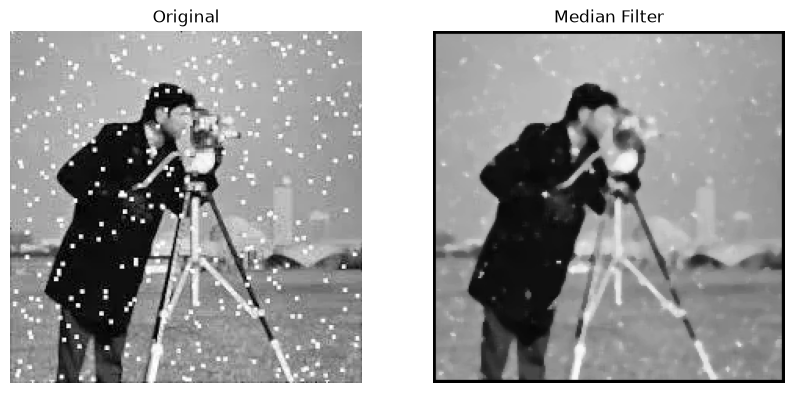

In [50]:
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(image, cmap="gray")
plt.title("Original")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(filtered_image, cmap="gray")
plt.title("Median Filter")
plt.axis("off")

plt.show()

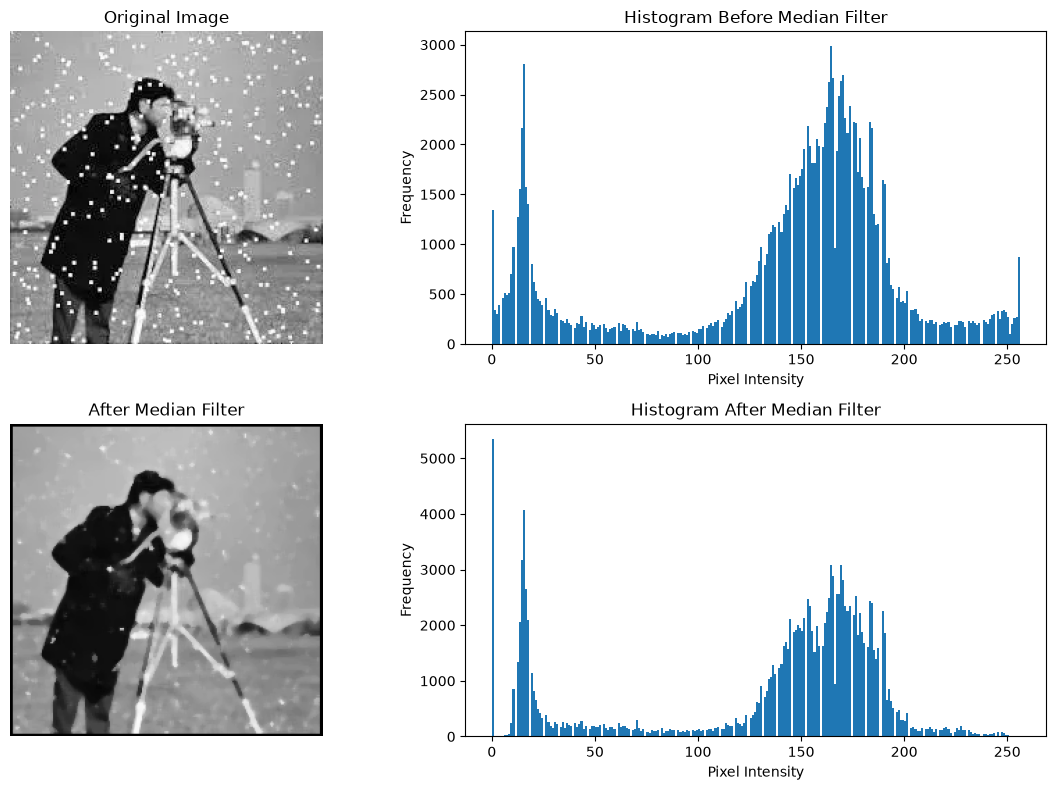

In [51]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 8))

# 1. Original image
plt.subplot(2, 2, 1)
plt.imshow(image, cmap="gray")
plt.title("Original Image")
plt.axis("off")

# 2. Histogram before filtering
plt.subplot(2, 2, 2)
plt.hist(image.ravel(), bins=256, range=(0, 256))
plt.title("Histogram Before Median Filter")
plt.xlabel("Pixel Intensity")
plt.ylabel("Frequency")

# 3. Filtered image
plt.subplot(2, 2, 3)
plt.imshow(filtered_image, cmap="gray")
plt.title("After Median Filter")
plt.axis("off")

# 4. Histogram after filtering
plt.subplot(2, 2, 4)
plt.hist(filtered_image.ravel(), bins=256, range=(0, 256))
plt.title("Histogram After Median Filter")
plt.xlabel("Pixel Intensity")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

In [54]:
print(filtered_image.dtype)
print(filtered_image.shape)
print(filtered_image.min(), filtered_image.max())

uint8
(225, 225, 3)
0 251


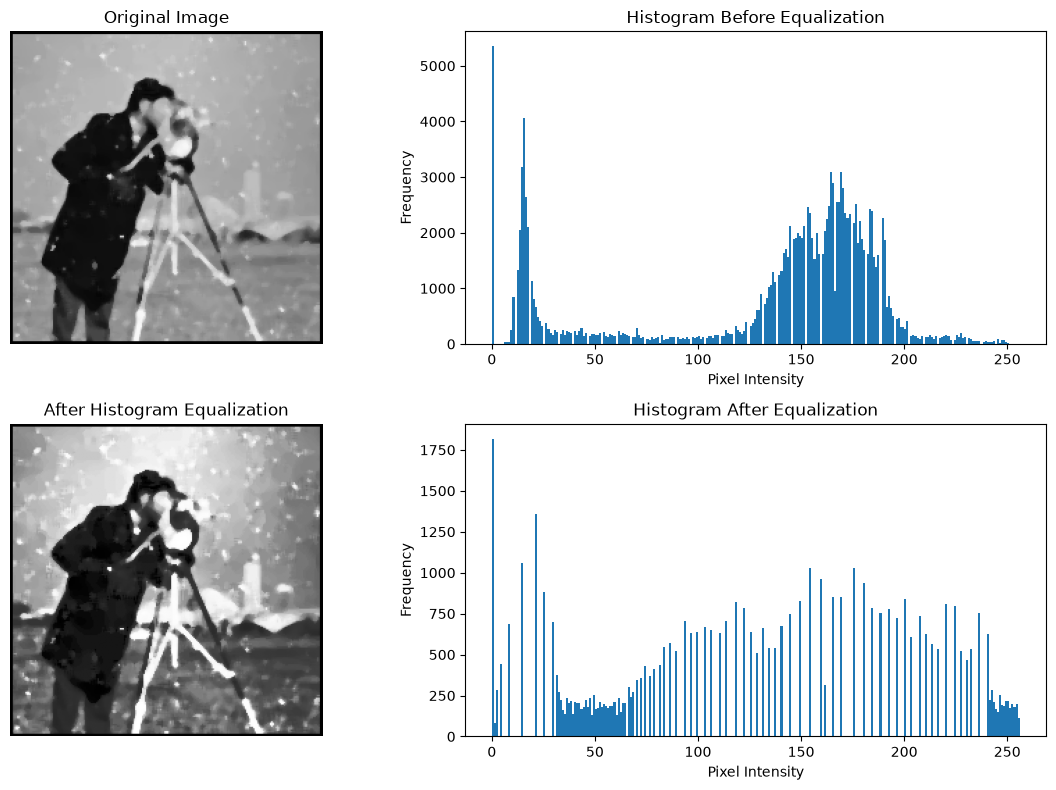

In [55]:
import cv2
import matplotlib.pyplot as plt

gray = cv2.cvtColor(filtered_image, cv2.COLOR_BGR2GRAY)

# Histogram equalization
equalized = cv2.equalizeHist(gray   )

plt.figure(figsize=(12, 8))

# Original image
plt.subplot(2, 2, 1)
plt.imshow(filtered_image, cmap="gray")
plt.title("Original Image")
plt.axis("off")

# Original histogram
plt.subplot(2, 2, 2)
plt.hist(filtered_image.ravel(), bins=256, range=(0, 256))
plt.title("Histogram Before Equalization")
plt.xlabel("Pixel Intensity")
plt.ylabel("Frequency")

# Equalized image
plt.subplot(2, 2, 3)
plt.imshow(equalized, cmap="gray")
plt.title("After Histogram Equalization")
plt.axis("off")

# Equalized histogram
plt.subplot(2, 2, 4)
plt.hist(equalized.ravel(), bins=256, range=(0, 256))
plt.title("Histogram After Equalization")
plt.xlabel("Pixel Intensity")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

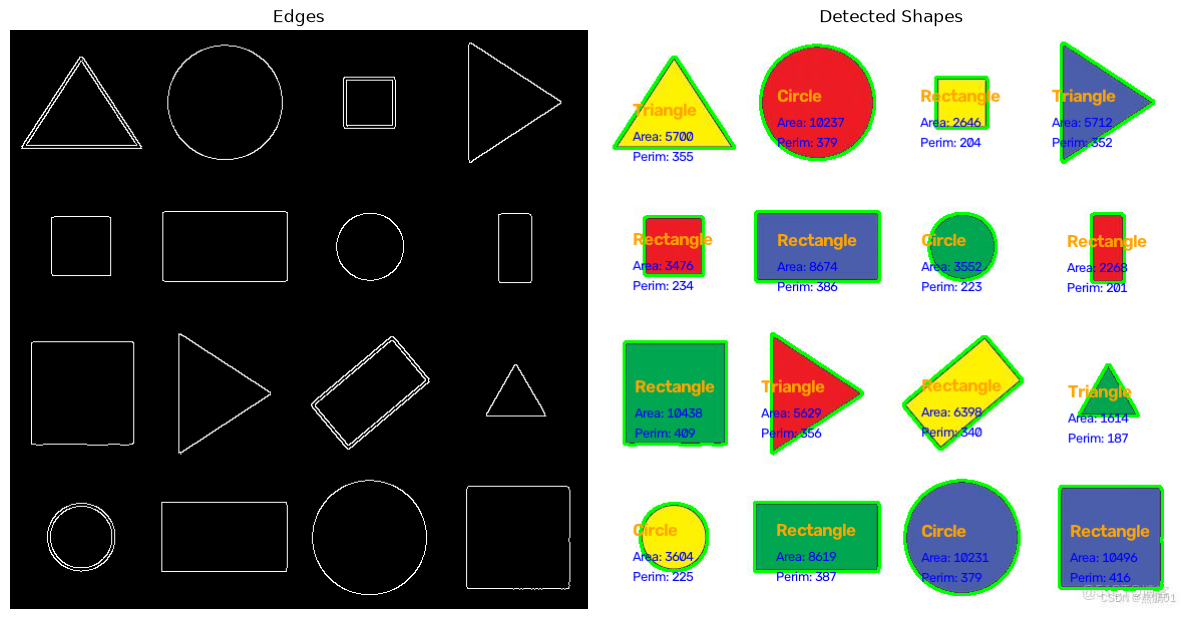

In [62]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

image = cv2.imread("shapes-more.jpeg")

# Keep original for drawing
output = image.copy()

# Grayscale
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

# Blur
blur = cv2.GaussianBlur(gray, (5, 5), 0)

# Edge detection
edges = cv2.Canny(blur, 50, 150)

# Find only external contours
contours, hierarchy = cv2.findContours(
    edges,
    cv2.RETR_EXTERNAL,
    cv2.CHAIN_APPROX_SIMPLE
)

for contour in contours:

    # Ignore very small contours
    area = cv2.contourArea(contour)

    if area < 500:
        continue

    # Perimeter
    perimeter = cv2.arcLength(contour, True)

    # Approximate contour
    epsilon = 0.04 * perimeter

    approx = cv2.approxPolyDP(
        contour,
        epsilon,
        True
    )

    vertices = len(approx)

    # Shape classification
    if vertices == 3:
        shape = "Triangle"

    elif vertices == 4:
        shape = "Rectangle"

    elif vertices == 5:
        shape = "Pentagon"

    else:
        shape = "Circle"

    # Draw contour
    cv2.drawContours(
        output,
        [contour],
        -1,
        (0, 255, 0),
        2
    )

    # Center of contour
    M = cv2.moments(contour)

    if M["m00"] != 0:

        cx = int(M["m10"] / M["m00"])
        cy = int(M["m01"] / M["m00"])

        # Display shape
        cv2.putText(
            output,
            shape,
            (cx - 40, cy),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.6,
            (0, 165, 255),
            2
        )

        # Display area
        cv2.putText(
            output,
            f"Area: {area:.0f}",
            (cx - 40, cy + 25),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.45,
            (255, 0, 0),
            1
        )

        # Display perimeter
        cv2.putText(
            output,
            f"Perim: {perimeter:.0f}",
            (cx - 40, cy + 45),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.45,
            (255, 0, 0),
            1
        )

# Display
plt.figure(figsize=(12, 8))

plt.subplot(1, 2, 1)
plt.imshow(cv2.cvtColor(edges, cv2.COLOR_BGR2RGB)
           if len(edges.shape) == 3 else edges,
           cmap="gray")
plt.title("Edges")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(cv2.cvtColor(output, cv2.COLOR_BGR2RGB))
plt.title("Detected Shapes")
plt.axis("off")

plt.tight_layout()
plt.show()

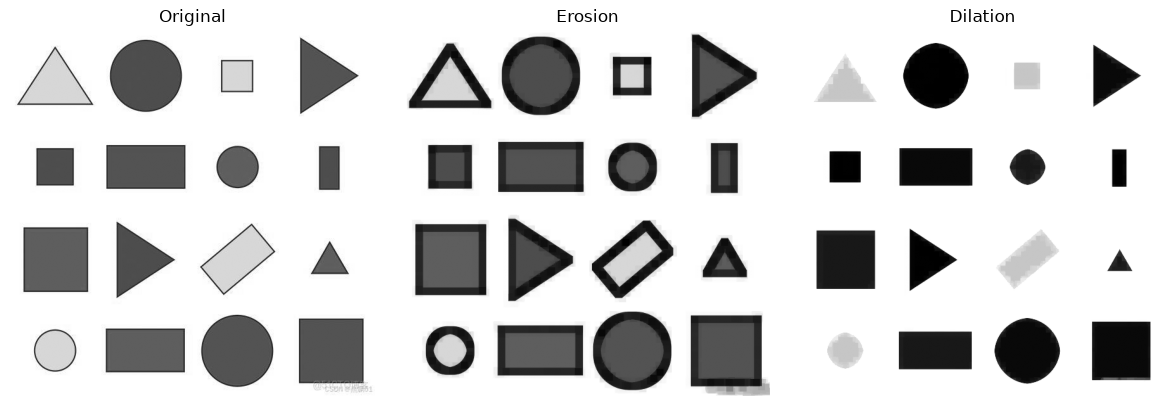

In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

image = cv2.imread("shapes-more.jpeg", cv2.IMREAD_GRAYSCALE)

kernel = np.ones((3, 3), np.uint8)

eroded = cv2.erode(image, kernel, iterations=5)

dilated = cv2.dilate(image, kernel, iterations=5)

plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.imshow(image, cmap="gray")
plt.title("Original")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(eroded, cmap="gray")
plt.title("Erosion")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(dilated, cmap="gray")
plt.title("Dilation")
plt.axis("off")

plt.tight_layout()
plt.show()

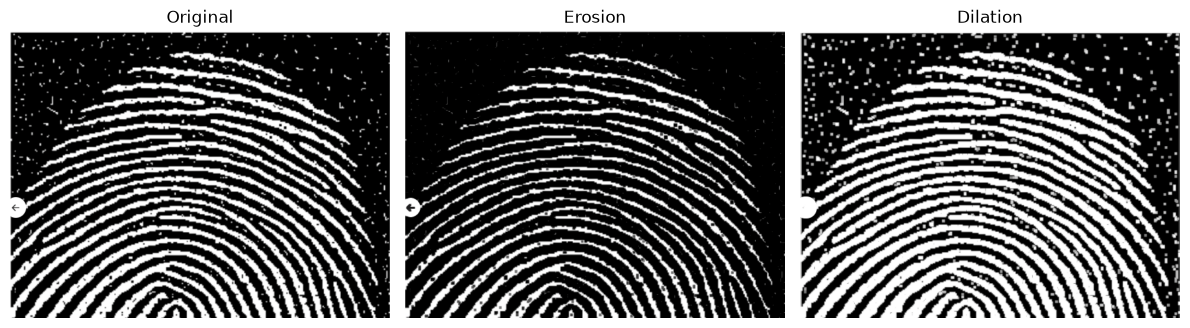

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Read image
image = cv2.imread("finger.png")

# Kernel
kernel = np.ones((3, 3), np.uint8)

# Erosion
eroded = cv2.erode(
    image,
    kernel,
    iterations=1
)

# Dilation
dilated = cv2.dilate(
    image,
    kernel,
    iterations=1
)

# Display
plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
plt.title("Original")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(cv2.cvtColor(eroded, cv2.COLOR_BGR2RGB))
plt.title("Erosion")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(cv2.cvtColor(dilated, cv2.COLOR_BGR2RGB))
plt.title("Dilation")
plt.axis("off")

plt.tight_layout()
plt.show()

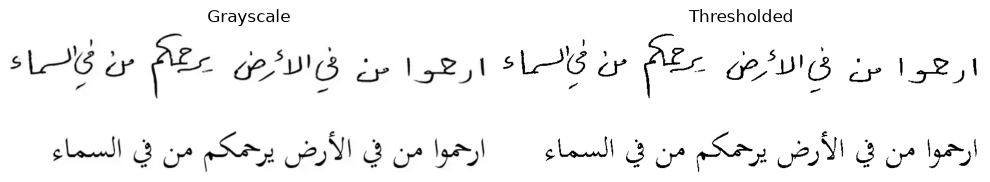

In [3]:
import cv2
import matplotlib.pyplot as plt

# Read image
image = cv2.imread("handwrite.webp")

# Convert to grayscale
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

# Apply threshold
threshold_value = 128

_, thresholded = cv2.threshold(
    gray,
    threshold_value,
    255,
    cv2.THRESH_BINARY
)

# Show results
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.imshow(gray, cmap="gray")
plt.title("Grayscale")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(thresholded, cmap="gray")
plt.title("Thresholded")
plt.axis("off")

plt.tight_layout()
plt.show()

Otsu calculated threshold: 171.0


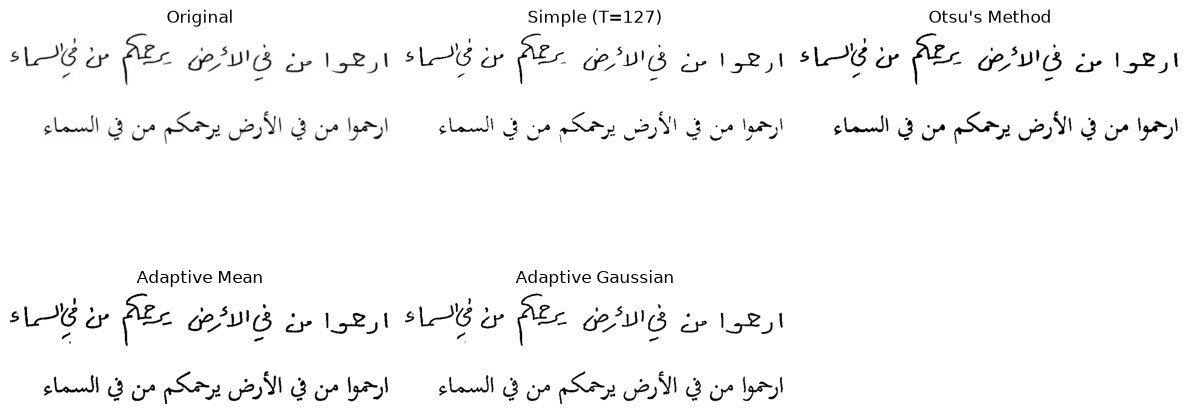

In [4]:
import cv2
import matplotlib.pyplot as plt

# 1. Load image in grayscale
image = cv2.imread('handwrite.webp', cv2.IMREAD_GRAYSCALE)

# Preprocessing: Apply Gaussian blur to reduce high-frequency noise
blurred = cv2.GaussianBlur(image, (5, 5), 0)

# --- METHOD 1: Simple Global Thresholding ---
# Hardcoded threshold at 127
_, thresh_simple = cv2.threshold(blurred, 127, 255, cv2.THRESH_BINARY)

# --- METHOD 2: Otsu's Automatic Binarization ---
# Automatically computes optimal threshold by analyzing histogram bimodal peaks
otsu_val, thresh_otsu = cv2.threshold(blurred, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
print(f"Otsu calculated threshold: {otsu_val}")

# --- METHOD 3: Adaptive Mean Thresholding ---
# Local threshold = Mean of 11x11 neighborhood minus C=2
thresh_adapt_mean = cv2.adaptiveThreshold(
    blurred, 255, cv2.ADAPTIVE_THRESH_MEAN_C, cv2.THRESH_BINARY, 11, 2
)

# --- METHOD 4: Adaptive Gaussian Thresholding ---
# Local threshold = Gaussian-weighted sum of 11x11 neighborhood minus C=2
thresh_adapt_gauss = cv2.adaptiveThreshold(
    blurred, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY, 11, 2
)

# Visualizing results
titles = ['Original', 'Simple (T=127)', "Otsu's Method", 'Adaptive Mean', 'Adaptive Gaussian']
images = [image, thresh_simple, thresh_otsu, thresh_adapt_mean, thresh_adapt_gauss]

plt.figure(figsize=(12, 6))
for i in range(5):
    plt.subplot(2, 3, i + 1)
    plt.imshow(images[i], cmap='gray')
    plt.title(titles[i])
    plt.axis('off')

plt.tight_layout()
plt.show()

In [1]:
import cv2
import numpy as np

# Load image
image = cv2.imread('luffy.jpg')

# 1. Convert BGR to HSV
hsv = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)

# 2. Define range of blue color in HSV
lower_blue = np.array([100, 50, 50])
upper_blue = np.array([130, 255, 255])

# 3. Create binary mask (White = Blue regions, Black = Everything else)
mask = cv2.inRange(hsv, lower_blue, upper_blue)

# 4. Extract only the blue parts from original image
segmented_result = cv2.bitwise_and(image, image, mask=mask)

# --- COMPARISON LOGIC ---

# Convert 1-channel grayscale mask to 3-channel BGR so it can stack with BGR images
mask_3ch = cv2.cvtColor(mask, cv2.COLOR_GRAY2BGR)



In [2]:
# Add text labels directly onto each image for clear visual identification
labeled_orig = image.copy()
labeled_mask = mask_3ch.copy()
labeled_seg = segmented_result.copy()

font = cv2.FONT_HERSHEY_SIMPLEX
font_scale = 0.8
thickness = 2
color = (0, 255, 0) # Green text

cv2.putText(labeled_orig, '1. Original Image', (20, 40), font, font_scale, color, thickness)
cv2.putText(labeled_mask, '2. Binary Mask', (20, 40), font, font_scale, color, thickness)
cv2.putText(labeled_seg, '3. Segmented Result', (20, 40), font, font_scale, color, thickness)

# Option A: Stack side-by-side horizontally (best for standard/portrait photos)
horizontal_comparison = np.hstack((labeled_orig, labeled_mask, labeled_seg))

# Save the combined side-by-side comparison image
cv2.imwrite('color_segmentation_comparison.png', horizontal_comparison)

# Display the window (press any key to exit)
cv2.imshow('Color Segmentation Comparison', horizontal_comparison)
cv2.waitKey(0)
cv2.destroyAllWindows()

In [7]:
import cv2
import numpy as np

# 1. Load image and convert to grayscale
image = cv2.imread('handwrite.webp', cv2.COLOR_BGR2GRAY)
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

# --- METHOD 1: Simple Binary Thresholding ---
# Pixels above 127 become white (255), pixels below become black (0)
_, simple_binary = cv2.threshold(gray, 127, 255, cv2.THRESH_BINARY)

# --- METHOD 2: Otsu's Automatic Binarization ---
# Automatically calculates the optimal global threshold value for bimodal images
_, otsu_binary = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

# --- METHOD 3: Adaptive Gaussian Thresholding ---
# Calculates threshold per-pixel neighborhood (handles shadows & uneven lighting)
adaptive_binary = cv2.adaptiveThreshold(
    gray, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY, 11, 2
)

# --- VISUAL COMPARISON GRID ---

# Convert single-channel binary maps to 3-channel BGR for stacking
gray_3ch = cv2.cvtColor(gray, cv2.COLOR_GRAY2BGR)
simple_3ch = cv2.cvtColor(simple_binary, cv2.COLOR_GRAY2BGR)
otsu_3ch = cv2.cvtColor(otsu_binary, cv2.COLOR_GRAY2BGR)
adaptive_3ch = cv2.cvtColor(adaptive_binary, cv2.COLOR_GRAY2BGR)

# Add text labels
font, font_scale, color, thickness = cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 255, 0), 2

cv2.putText(gray_3ch, '1. Grayscale', (20, 40), font, font_scale, color, thickness)
cv2.putText(simple_3ch, '2. Simple Threshold (127)', (20, 40), font, font_scale, color, thickness)
cv2.putText(otsu_3ch, "3. Otsu's Auto Binary", (20, 40), font, font_scale, color, thickness)
cv2.putText(adaptive_3ch, '4. Adaptive Threshold', (20, 40), font, font_scale, color, thickness)

# Combine into a 2x2 visual comparison grid
top_row = np.hstack((gray_3ch, simple_3ch))
bottom_row = np.hstack((otsu_3ch, adaptive_3ch))
binary_comparison = np.vstack((top_row, bottom_row))

# Save and show result
cv2.imwrite('binary_conversion_comparison.png', binary_comparison)
cv2.imshow('Binary Conversion Comparison', binary_comparison)
cv2.waitKey(0)
cv2.destroyAllWindows()

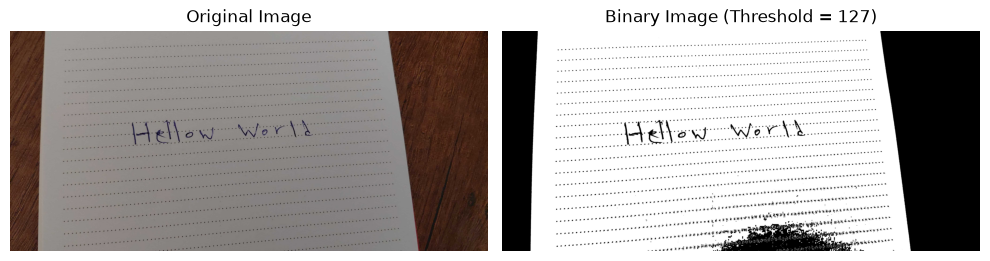

In [8]:
import cv2
import matplotlib.pyplot as plt

# 1. Load image and convert to grayscale
image_bgr = cv2.imread('test.jpg')
gray = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2GRAY)

# 2. Apply Simple Binary Thresholding
# Pixels > 127 become 255 (white), pixels <= 127 become 0 (black)
threshold_value = 127
max_value = 255
_, binary_image = cv2.threshold(gray, threshold_value, max_value, cv2.THRESH_BINARY)

# 3. Convert original BGR image to RGB for correct rendering in Matplotlib
image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)

# 4. Display side-by-side using Matplotlib
plt.figure(figsize=(10, 5))

# Original Image
plt.subplot(1, 2, 1)
plt.imshow(image_rgb)
plt.title('Original Image')
plt.axis('off')

# Binary Image
plt.subplot(1, 2, 2)
plt.imshow(binary_image, cmap='gray')
plt.title(f'Binary Image (Threshold = {threshold_value})')
plt.axis('off')

plt.tight_layout()
plt.show()

Otsu threshold: 93.0


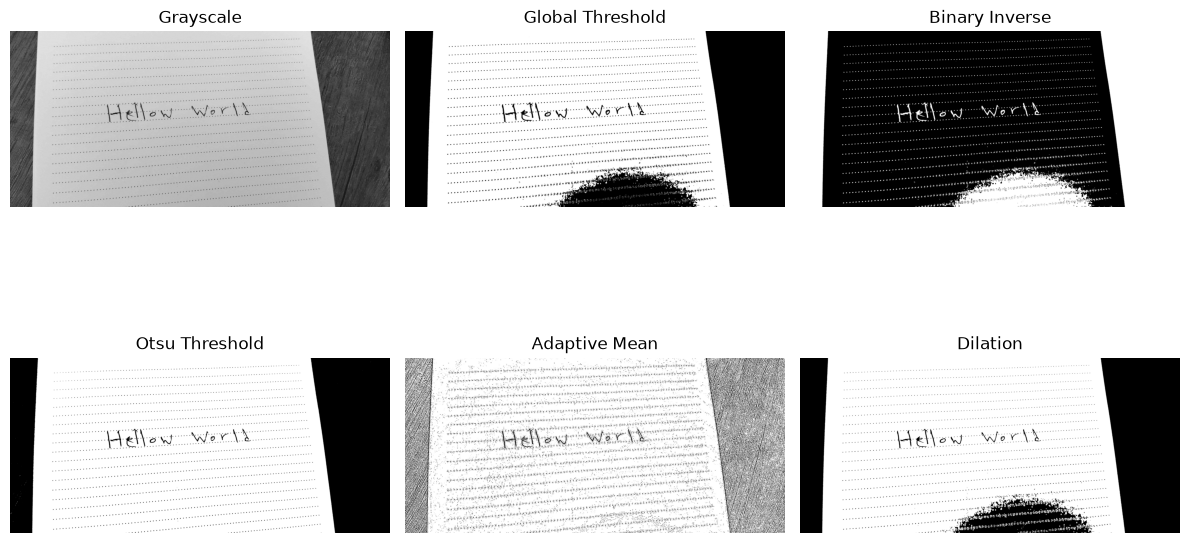

In [15]:
import cv2
import matplotlib.pyplot as plt

# Read image
image = cv2.imread("test.jpg")

# Convert to grayscale
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)


# Kernel
kernel = np.ones((3, 3), np.uint8)
# -------------------------------------------------
# 1. Global Binary Threshold
# -------------------------------------------------
_, binary = cv2.threshold(
    gray, 128, 255, cv2.THRESH_BINARY
)

# -------------------------------------------------
# 2. Binary Inverse Threshold
# -------------------------------------------------
_, binary_inv = cv2.threshold(
    gray, 128, 255, cv2.THRESH_BINARY_INV
)

# -------------------------------------------------
# 3. Otsu Thresholding
# -------------------------------------------------
otsu_value, otsu = cv2.threshold(
    gray, 0, 255,
    cv2.THRESH_BINARY + cv2.THRESH_OTSU
)

print("Otsu threshold:", otsu_value)

# -------------------------------------------------
# 4. Adaptive Mean Thresholding
# -------------------------------------------------
adaptive_mean = cv2.adaptiveThreshold(
    gray,
    255,
    cv2.ADAPTIVE_THRESH_MEAN_C,
    cv2.THRESH_BINARY,
    11,
    2
)

# -------------------------------------------------
# 5. Adaptive Gaussian Thresholding
# -------------------------------------------------
adaptive_gaussian = cv2.adaptiveThreshold(
    gray,
    255,
    cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
    cv2.THRESH_BINARY,
    11,
    2
)


dilated = cv2.dilate(
    binary,
    kernel,
    iterations=1
)

# -------------------------------------------------
# Display all results using Matplotlib
# -------------------------------------------------

plt.figure(figsize=(12, 8))

plt.subplot(2, 3, 1)
plt.imshow(gray, cmap="gray")
plt.title("Grayscale")
plt.axis("off")

plt.subplot(2, 3, 2)
plt.imshow(binary, cmap="gray")
plt.title("Global Threshold")
plt.axis("off")

plt.subplot(2, 3, 3)
plt.imshow(binary_inv, cmap="gray")
plt.title("Binary Inverse")
plt.axis("off")

plt.subplot(2, 3, 4)
plt.imshow(otsu, cmap="gray")
plt.title("Otsu Threshold")
plt.axis("off")

plt.subplot(2, 3, 5)
plt.imshow(adaptive_mean, cmap="gray")
plt.title("Adaptive Mean")
plt.axis("off")

plt.subplot(2, 3, 6)
plt.imshow(dilated, cmap="gray")
plt.title("Dilation")
plt.axis("off")

plt.tight_layout()
plt.show()

Otsu automatically calculated optimal threshold: 190.0


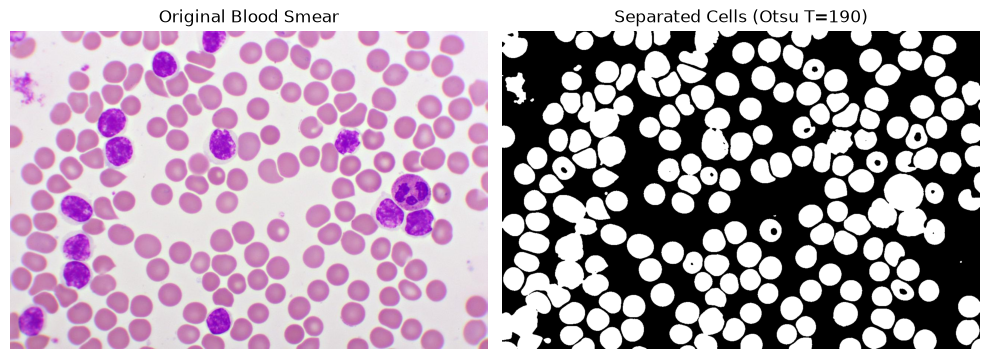

In [10]:
import cv2
import matplotlib.pyplot as plt

# 1. Load image and convert to grayscale
image_bgr = cv2.imread('bloodcells.jpeg')
gray = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2GRAY)

# 2. Apply Gaussian Blur to smooth out cell texture noise
blurred = cv2.GaussianBlur(gray, (5, 5), 0)

# 3. Apply Otsu's Thresholding (Inverted to make cells WHITE and background BLACK)
# cv2.THRESH_BINARY_INV separates dark cells from bright background
threshold_value, binary_cells = cv2.threshold(
    blurred, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU
)

print(f"Otsu automatically calculated optimal threshold: {threshold_value}")

# 4. Display using Matplotlib
image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(10, 5))

# Original Image
plt.subplot(1, 2, 1)
plt.imshow(image_rgb)
plt.title('Original Blood Smear')
plt.axis('off')

# Separated Blood Cells
plt.subplot(1, 2, 2)
plt.imshow(binary_cells, cmap='gray')
plt.title(f'Separated Cells (Otsu T={int(threshold_value)})')
plt.axis('off')

plt.tight_layout()
plt.show()

Total Blood Cells Detected: 15


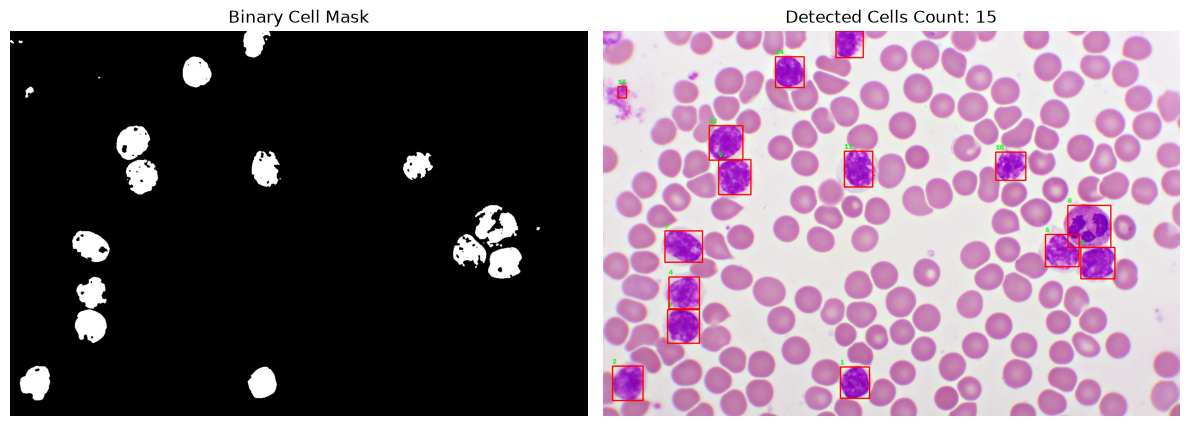

In [ ]:
import cv2
import matplotlib.pyplot as plt

# 1. Load image and convert to grayscale
image_bgr = cv2.imread('bloodcells.jpeg')
gray = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2GRAY)


# 2. Smooth noise and binarize (Inverted: Cells = WHITE, Background = BLACK)
blurred = cv2.GaussianBlur(gray, (5, 5), 0)
_, binary_cells = cv2.threshold(blurred, 128, 255, cv2.THRESH_BINARY_INV)

# 3. Optional: Clean up small noise points using Morphological Opening
kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (3, 3))
cleaned_binary = cv2.morphologyEx(binary_cells, cv2.MORPH_OPEN, kernel)

# 4. Find contours (outer boundaries of white blobs)
contours, _ = cv2.findContours(cleaned_binary, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

# 5. Count and label each cell on a copy of the original image
counted_image = image_bgr.copy()
min_cell_area = 50  # Filter out tiny dust/noise specs
cell_count = 0

for cnt in contours:
    # Filter by minimum area to avoid counting noise artifacts
    if cv2.contourArea(cnt) > min_cell_area:
        cell_count += 1
        
        # Get bounding box coordinates to draw outline and text
        x, y, w, h = cv2.boundingRect(cnt)
        
        # Draw red bounding box around the cell
        cv2.rectangle(counted_image, (x, y), (x + w, y + h), (0, 0, 255), 2)
        
        # Write the cell index number in green near the cell
        cv2.putText(
            counted_image, str(cell_count), (x, y - 5), 
            cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 2
        )

print(f"Total Blood Cells Detected: {cell_count}")

# 6. Display results using Matplotlib
image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)
counted_rgb = cv2.cvtColor(counted_image, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.imshow(cleaned_binary, cmap='gray')
plt.title('Binary Cell Mask')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(counted_rgb)
plt.title(f'Detected Cells Count: {cell_count}')
plt.axis('off')

plt.tight_layout()
plt.show()

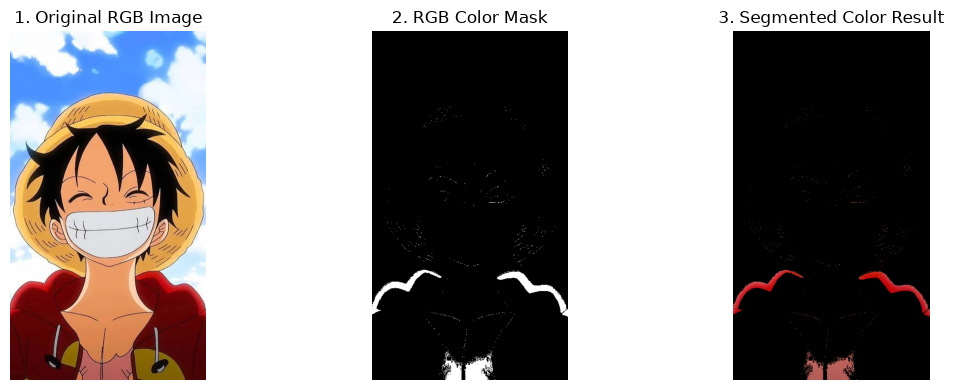

In [19]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

# 1. Load image and convert to RGB (OpenCV reads in BGR by default)
image_bgr = cv2.imread('luffy.jpg')
image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)

# 2. Define target color range directly in RGB
# Example: Targeting RED regions
# (Adjust these arrays to target different colors like Blue or Green)
lower_rgb = np.array([150, 0, 0])      # Minimum Red, Green, Blue
upper_rgb = np.array([255, 100, 100])  # Maximum Red, Green, Blue

# 3. Create Binary Mask (1/255 where RGB values fall within range, 0 elsewhere)
mask = cv2.inRange(image_rgb, lower_rgb, upper_rgb)

# 4. Extract target color regions using bitwise AND
segmented_rgb = cv2.bitwise_and(image_rgb, image_rgb, mask=mask)

# 5. Display results using Matplotlib
plt.figure(figsize=(12, 4))

# Original Image
plt.subplot(1, 3, 1)
plt.imshow(image_rgb)
plt.title('1. Original RGB Image')
plt.axis('off')

# Binary Mask
plt.subplot(1, 3, 2)
plt.imshow(mask, cmap='gray')
plt.title('2. RGB Color Mask')
plt.axis('off')

# Segmented Result
plt.subplot(1, 3, 3)
plt.imshow(segmented_rgb)
plt.title('3. Segmented Color Result')
plt.axis('off')

plt.tight_layout()
plt.show()

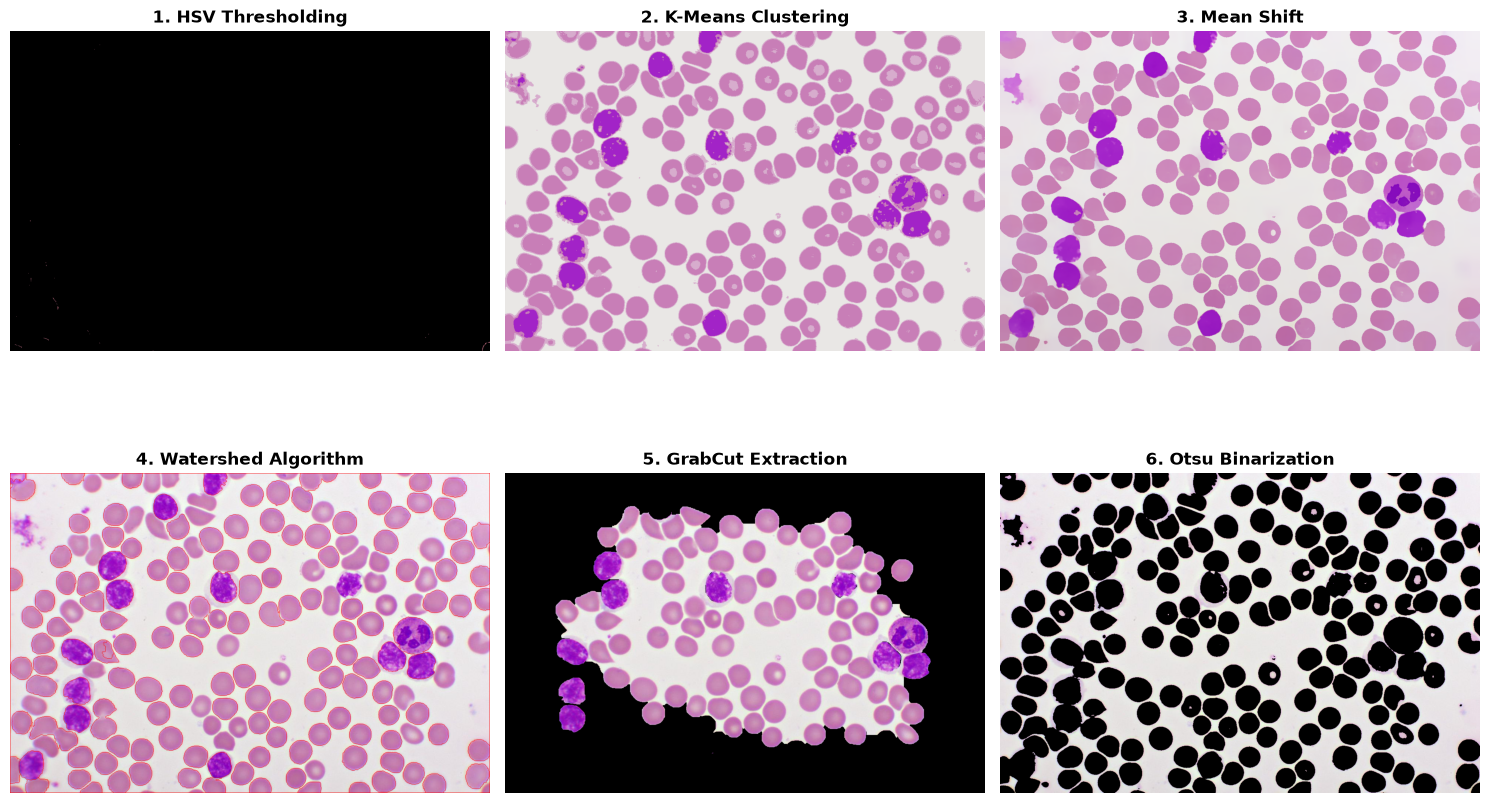

In [20]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# 1. Load image and convert to RGB
image_bgr = cv2.imread('bloodcells.jpeg')
image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)

# ---------------------------------------------------------
# METHOD 1: HSV Color Thresholding (Isolating specific hue)
# ---------------------------------------------------------
hsv = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2HSV)
lower_red1 = np.array([0, 100, 50])
upper_red1 = np.array([10, 255, 255])
lower_red2 = np.array([170, 100, 50])
upper_red2 = np.array([180, 255, 255])
mask_hsv = cv2.inRange(hsv, lower_red1, upper_red1) + cv2.inRange(hsv, lower_red2, upper_red2)
res_hsv = cv2.bitwise_and(image_rgb, image_rgb, mask=mask_hsv)

# ---------------------------------------------------------
# METHOD 2: K-Means Clustering (Color Quantization/Groupings)
# ---------------------------------------------------------
pixel_values = image_rgb.reshape((-1, 3)).astype(np.float32)
criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 100, 0.2)
K = 4  # Number of distinct color clusters
_, labels, centers = cv2.kmeans(pixel_values, K, None, criteria, 10, cv2.KMEANS_RANDOM_CENTERS)
centers = np.uint8(centers)
res_kmeans = centers[labels.flatten()].reshape(image_rgb.shape)

# ---------------------------------------------------------
# METHOD 3: Mean Shift Segmentation (Smooth Color Clustering)
# ---------------------------------------------------------
# spatialWindowRadius=21, colorWindowRadius=51
res_meanshift = cv2.pyrMeanShiftFiltering(image_bgr, sp=21, sr=51)
res_meanshift = cv2.cvtColor(res_meanshift, cv2.COLOR_BGR2RGB)

# ---------------------------------------------------------
# METHOD 4: Watershed Algorithm (Marker-based region separation)
# ---------------------------------------------------------
gray = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2GRAY)
_, thresh = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)

# Noise removal via Morphological Opening
kernel = np.ones((3, 3), np.uint8)
opening = cv2.morphologyEx(thresh, cv2.MORPH_OPEN, kernel, iterations=2)

# Finding sure background and sure foreground areas
sure_bg = cv2.dilate(opening, kernel, iterations=3)
dist_transform = cv2.distanceTransform(opening, cv2.DIST_L2, 5)
_, sure_fg = cv2.threshold(dist_transform, 0.5 * dist_transform.max(), 255, 0)
sure_fg = np.uint8(sure_fg)

# Unknown region between foreground and background
unknown = cv2.subtract(sure_bg, sure_fg)

# Marker labeling
_, markers = cv2.connectedComponents(sure_fg)
markers = markers + 1  # Add 1 so background is 1 instead of 0
markers[unknown == 255] = 0

# Apply Watershed algorithm
markers = cv2.watershed(image_bgr.copy(), markers)

# Color boundaries red (-1 indicates watershed boundary)
res_watershed = image_rgb.copy()
res_watershed[markers == -1] = [255, 0, 0]

# ---------------------------------------------------------
# METHOD 5: GrabCut Algorithm (Foreground/Background Extraction)
# ---------------------------------------------------------
mask_gc = np.zeros(image_bgr.shape[:2], np.uint8)
bgdModel = np.zeros((1, 65), np.float64)
fgdModel = np.zeros((1, 65), np.float64)

# Define a central bounding box rectangle [x, y, width, height] containing the target
h, w = image_bgr.shape[:2]
rect = (int(w * 0.1), int(h * 0.1), int(w * 0.8), int(h * 0.8))

cv2.grabCut(image_bgr, mask_gc, rect, bgdModel, fgdModel, 5, cv2.GC_INIT_WITH_RECT)
mask_gc2 = np.where((mask_gc == 2) | (mask_gc == 0), 0, 1).astype('uint8')
res_grabcut = image_rgb * mask_gc2[:, :, np.newaxis]

# ---------------------------------------------------------
# METHOD 6: Otsu's Multi-Level/Binarization Masking
# ---------------------------------------------------------
_, otsu_mask = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
res_otsu = cv2.bitwise_and(image_rgb, image_rgb, mask=otsu_mask)

# ---------------------------------------------------------
# DISPLAY RESULTS IN A 2x3 GRID
# ---------------------------------------------------------
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

titles_and_images = [
    ("1. HSV Thresholding", res_hsv),
    ("2. K-Means Clustering", res_kmeans),
    ("3. Mean Shift", res_meanshift),
    ("4. Watershed Algorithm", res_watershed),
    ("5. GrabCut Extraction", res_grabcut),
    ("6. Otsu Binarization", res_otsu)
]

for ax, (title, img) in zip(axes.ravel(), titles_and_images):
    ax.imshow(img)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.axis('off')

plt.tight_layout()
plt.show()

Initial markers: 165
Total cells: 164


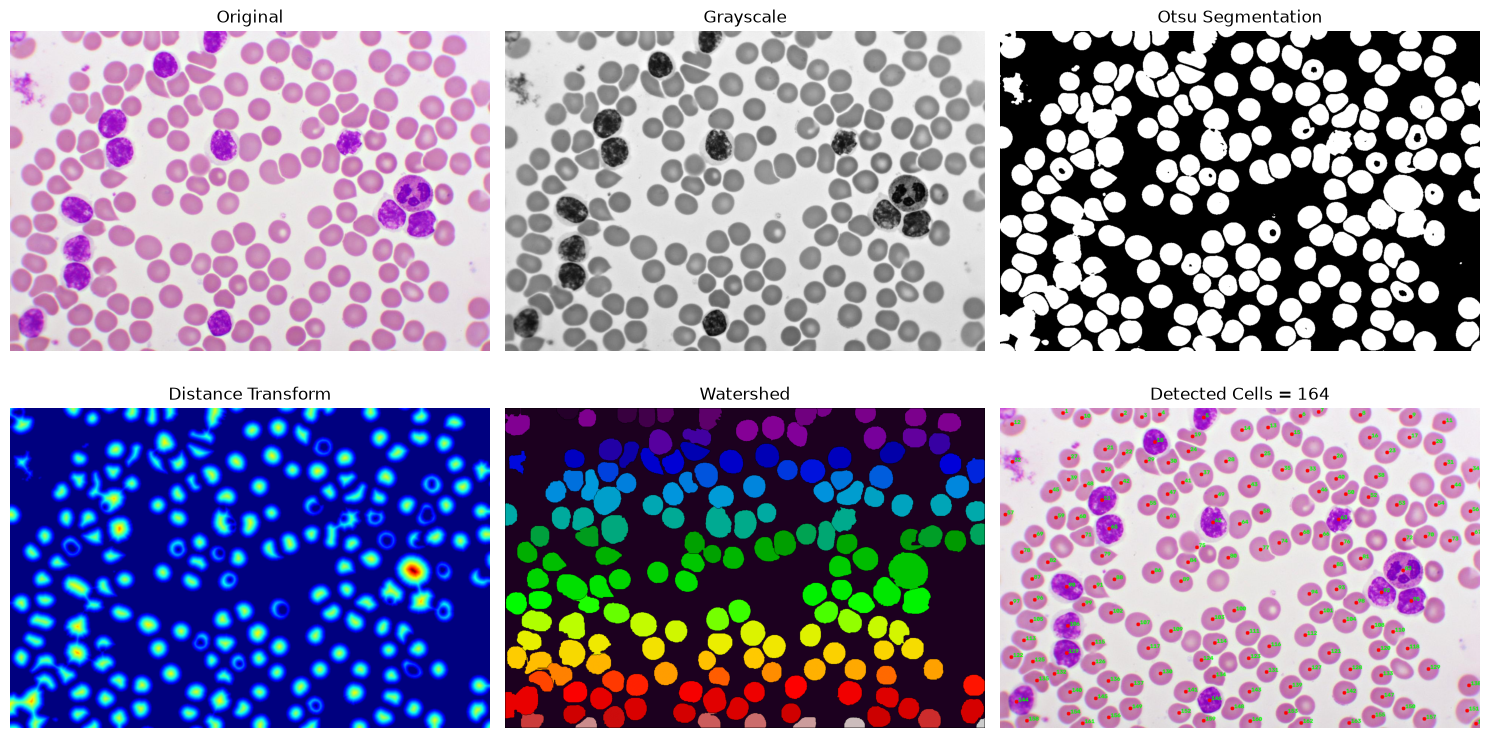

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# =========================================
# 1. Read image
# =========================================

image = cv2.imread(
    "bloodcells.jpeg"
)

if image is None:
    print("Image not found!")
    exit()

gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)


# =========================================
# 2. Segmentation using Otsu
# =========================================

_, binary = cv2.threshold(
    gray,
    0,
    255,
    cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU
)


# =========================================
# 3. Remove noise
# =========================================

kernel = np.ones((3, 3), np.uint8)

opening = cv2.morphologyEx(
    binary,
    cv2.MORPH_OPEN,
    kernel,
    iterations=2
)


# =========================================
# 4. Sure Background
# =========================================

sure_bg = cv2.dilate(
    opening,
    kernel,
    iterations=3
)


# =========================================
# 5. Distance Transform
# =========================================

dist_transform = cv2.distanceTransform(
    opening,
    cv2.DIST_L2,
    5
)


# =========================================
# 6. Sure Foreground
# =========================================
# 0.4 يمكن تغييرها إلى 0.3 أو 0.5

_, sure_fg = cv2.threshold(
    dist_transform,
    0.4 * dist_transform.max(),
    255,
    0
)

sure_fg = np.uint8(sure_fg)


# =========================================
# 7. Unknown Region
# =========================================

unknown = cv2.subtract(
    sure_bg,
    sure_fg
)


# =========================================
# 8. Create markers
# =========================================

num_markers, markers = cv2.connectedComponents(
    sure_fg
)

print("Initial markers:", num_markers - 1)

# Background = 1
markers = markers + 1

# Unknown = 0
markers[unknown == 255] = 0


# =========================================
# 9. Watershed
# =========================================

markers = cv2.watershed(
    image,
    markers
)


# =========================================
# 10. Count cells
# =========================================

cell_count = 0

result = image.copy()

for label in range(2, num_markers + 1):

    mask = np.zeros(gray.shape, dtype=np.uint8)

    mask[markers == label] = 255

    area = cv2.countNonZero(mask)

    # Ignore very small regions
    if area > 100:

        cell_count += 1

        # Find center
        M = cv2.moments(mask)

        if M["m00"] != 0:

            cx = int(M["m10"] / M["m00"])
            cy = int(M["m01"] / M["m00"])

            # Draw center
            cv2.circle(
                result,
                (cx, cy),
                5,
                (0, 0, 255),
                -1
            )

            # Number cell
            cv2.putText(
                result,
                str(cell_count),
                (cx + 5, cy),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.5,
                (0, 255, 0),
                2
            )


print("Total cells:", cell_count)


# =========================================
# 11. Display
# =========================================

plt.figure(figsize=(15, 8))

plt.subplot(2, 3, 1)
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
plt.title("Original")
plt.axis("off")

plt.subplot(2, 3, 2)
plt.imshow(gray, cmap="gray")
plt.title("Grayscale")
plt.axis("off")

plt.subplot(2, 3, 3)
plt.imshow(binary, cmap="gray")
plt.title("Otsu Segmentation")
plt.axis("off")

plt.subplot(2, 3, 4)
plt.imshow(dist_transform, cmap="jet")
plt.title("Distance Transform")
plt.axis("off")

plt.subplot(2, 3, 5)
plt.imshow(markers, cmap="nipy_spectral")
plt.title("Watershed")
plt.axis("off")

plt.subplot(2, 3, 6)
plt.imshow(cv2.cvtColor(result, cv2.COLOR_BGR2RGB))
plt.title(f"Detected Cells = {cell_count}")
plt.axis("off")

plt.tight_layout()
plt.show()